# 1. Import Libraries


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mng_utoronto_2021_clinical_data.tsv to mng_utoronto_2021_clinical_data (1).tsv


## 2. Load Clinical Genomics Dataset


In [ ]:
import pandas as pd

df = pd.read_csv("mng_utoronto_2021_clinical_data.tsv", sep="\t")

df.head()

,Study ID,Patient ID,Sample ID,Cancer Type,Molecular Group,Mutation Count,Tumor Recurrence,Number of Samples Per Patient,TMB (nonsynonymous),World Health Organization (WHO) Grade
0,mng_utoronto_2021,CAM20-0001,CAM20-0001,Meningioma,hypermetabolic,9.0,yes,1,0.300000,G1
1,mng_utoronto_2021,CAM20-0002,CAM20-0002,Meningioma,Immunogenic,4.0,no,1,0.133333,G1
2,mng_utoronto_2021,CAM20-0003,CAM20-0003,Meningioma,MG2,2.0,no,1,0.066667,G1
3,mng_utoronto_2021,CAM20-0004,CAM20-0004,Meningioma,MG2,1.0,no,1,0.033333,G1
4,mng_utoronto_2021,CAM20-0005,CAM20-0005,Meningioma,MG2,3.0,yes,1,0.100000,G1


In [ ]:
df.columns

Index(['Study ID', 'Patient ID', 'Sample ID', 'Cancer Type', 'Molecular Group',
       'Mutation Count', 'Tumor Recurrence', 'Number of Samples Per Patient',
       'TMB (nonsynonymous)', 'World Health Organization (WHO) Grade'],
      dtype='object')

## 3. Create SQLite Database


In [ ]:
import pandas as pd
import sqlite3
# read TSV
df = pd.read_csv("mng_utoronto_2021_clinical_data.tsv", sep="\t")
# create sqlite database
conn = sqlite3.connect("genomics.db")
# convert dataframe to SQL table
df.to_sql("oncology_samples",
          conn,
          if_exists="replace",
          index=False)

print("Table created!")



Table created!


## 4. Molecular Group Analysis


In [ ]:
query = """
SELECT [Molecular Group],
COUNT(*) AS patient_count
FROM oncology_samples
GROUP BY [Molecular Group]
ORDER BY patient_count DESC
"""

pd.read_sql(query, conn)


,Molecular Group,patient_count
0,hypermetabolic,43
1,MG2,32
2,proliferative,29
3,Immunogenic,17


In [ ]:
query = """
SELECT [Molecular Group],
AVG([Mutation Count]) AS avg_mutation_count
FROM oncology_samples
GROUP BY [Molecular Group]
ORDER BY avg_mutation_count DESC
"""

pd.read_sql(query, conn)


,Molecular Group,avg_mutation_count
0,proliferative,17.642857
1,hypermetabolic,9.121951
2,MG2,7.966667
3,Immunogenic,7.875000


## 5. Tumor Mutation Burden (TMB) Analysis


In [ ]:
query = """
SELECT [Molecular Group],
AVG([TMB (nonsynonymous)]) AS avg_tmb
FROM oncology_samples
GROUP BY [Molecular Group]
ORDER BY avg_tmb DESC
"""

pd.read_sql(query, conn)


,Molecular Group,avg_tmb
0,proliferative,0.589286
1,hypermetabolic,0.304065
2,MG2,0.265556
3,Immunogenic,0.262500


## 6. Tumor Recurrence Analysis


In [ ]:
query = """
SELECT [Molecular Group],
[Tumor Recurrence],
COUNT(*) AS count
FROM oncology_samples
GROUP BY [Molecular Group],
[Tumor Recurrence]
ORDER BY count DESC
"""

pd.read_sql(query, conn)

,Molecular Group,Tumor Recurrence,count
0,proliferative,yes,25
1,hypermetabolic,yes,24
2,MG2,no,20
3,hypermetabolic,no,19
4,Immunogenic,no,14
5,MG2,yes,12
6,proliferative,no,4
7,Immunogenic,yes,3


In [ ]:
query = """
SELECT
    [Molecular Group],
    ROUND(
        100.0 * SUM(
            CASE
                WHEN [Tumor Recurrence] = 'yes' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS recurrence_percentage
FROM oncology_samples
GROUP BY [Molecular Group]
ORDER BY recurrence_percentage DESC
"""

pd.read_sql(query, conn)


,Molecular Group,recurrence_percentage
0,proliferative,86.21
1,hypermetabolic,55.81
2,MG2,37.50
3,Immunogenic,17.65


## 7. WHO Grade Analysis


In [ ]:
query = """
SELECT [Molecular Group],
[World Health Organization (WHO) Grade],
COUNT(*) AS count
FROM oncology_samples
GROUP BY [Molecular Group],
[World Health Organization (WHO) Grade]
"""

pd.read_sql(query, conn)

,Molecular Group,World Health Organization (WHO) Grade,count
0,Immunogenic,G1,15
1,Immunogenic,G2,2
2,MG2,G1,21
3,MG2,G2,9
4,MG2,G3,2
5,hypermetabolic,G1,20
6,hypermetabolic,G2,18
7,hypermetabolic,G3,5
8,proliferative,G1,3
9,proliferative,G2,14


In [ ]:
query = """
SELECT
    [Molecular Group],
    [World Health Organization (WHO) Grade],
    COUNT(*) AS sample_count,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (
            PARTITION BY [Molecular Group]
        ),
        2
    ) AS percentage
FROM oncology_samples
GROUP BY
    [Molecular Group],
    [World Health Organization (WHO) Grade]
ORDER BY
    [Molecular Group],
    percentage DESC
"""

pd.read_sql(query, conn)

,Molecular Group,World Health Organization (WHO) Grade,sample_count,percentage
0,Immunogenic,G1,15,88.24
1,Immunogenic,G2,2,11.76
2,MG2,G1,21,65.63
3,MG2,G2,9,28.13
4,MG2,G3,2,6.25
5,hypermetabolic,G1,20,46.51
6,hypermetabolic,G2,18,41.86
7,hypermetabolic,G3,5,11.63
8,proliferative,G2,14,48.28
9,proliferative,G3,12,41.38


## 8. Data Visualization


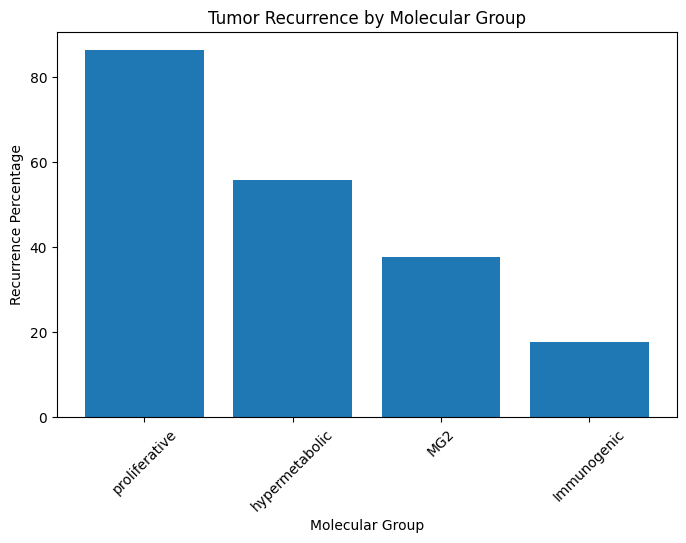

In [ ]:
import matplotlib.pyplot as plt

query = """
SELECT
    [Molecular Group],
    ROUND(
        100.0 * SUM(
            CASE
                WHEN [Tumor Recurrence] = 'yes' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS recurrence_percentage
FROM oncology_samples
GROUP BY [Molecular Group]
ORDER BY recurrence_percentage DESC
"""

df_plot = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))
plt.bar(df_plot["Molecular Group"],
        df_plot["recurrence_percentage"])

plt.xlabel("Molecular Group")
plt.ylabel("Recurrence Percentage")
plt.title("Tumor Recurrence by Molecular Group")
plt.xticks(rotation=45)

plt.show()

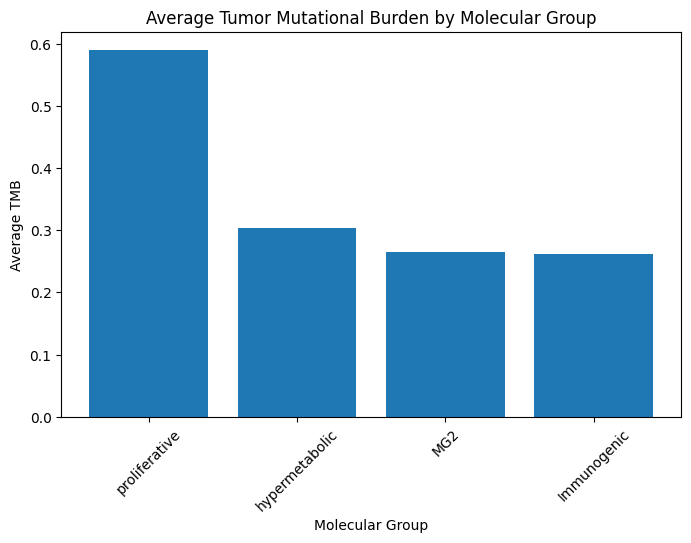

In [ ]:
query = """
SELECT
    [Molecular Group],
    AVG([TMB (nonsynonymous)]) AS avg_tmb
FROM oncology_samples
GROUP BY [Molecular Group]
ORDER BY avg_tmb DESC
"""

df_plot = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))
plt.bar(df_plot["Molecular Group"],
        df_plot["avg_tmb"])

plt.xlabel("Molecular Group")
plt.ylabel("Average TMB")
plt.title("Average Tumor Mutational Burden by Molecular Group")
plt.xticks(rotation=45)

plt.show()

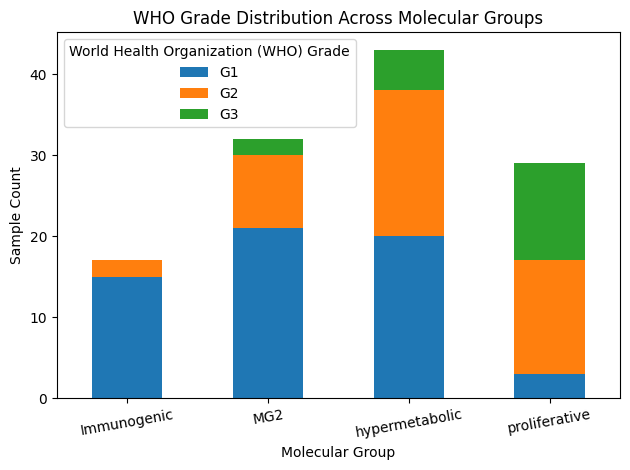

In [ ]:
query = """
SELECT
    [Molecular Group],
    [World Health Organization (WHO) Grade],
    COUNT(*) AS count
FROM oncology_samples
GROUP BY
    [Molecular Group],
    [World Health Organization (WHO) Grade]
"""

df_grade = pd.read_sql(query, conn)

pivot_df = df_grade.pivot(
    index="Molecular Group",
    columns="World Health Organization (WHO) Grade",
    values="count"
)

pivot_df.plot(kind="bar", stacked=True)

plt.xlabel("Molecular Group")
plt.ylabel("Sample Count")
plt.title("WHO Grade Distribution Across Molecular Groups")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


Explored differences in WHO grade distribution across molecular groups in meningioma samples.
Analyzed tumor recurrence and mutation burden patterns using SQL based aggregation.
Compared molecular subgroup characteristics through data visualization.
Demonstrated SQL querying, healthcare data analysis, and clinical genomics interpretation skills.
